# Data Loading

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("online_retail_II.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print(df.shape)

df.info()

df.describe(include="all")

(1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628,5305,5698,NaN,47635,NaN,NaN,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2010-12-06 16:57:00,NaN,NaN,United Kingdom
freq,1350,5829,5918,NaN,1350,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,NaN,4.649388e+00,15324.638504,NaN
std,NaN,NaN,NaN,1.727058e+02,NaN,1.235531e+02,1697.464450,NaN
min,NaN,NaN,NaN,-8.099500e+04,NaN,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,NaN,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,NaN,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,NaN,4.150000e+00,16797.000000,NaN


In [4]:
missing = pd.DataFrame({

    "Missing Values":df.isnull().sum(),

    "Percentage":round(df.isnull().mean()*100,2)

})

missing.sort_values(
    "Percentage",
    ascending=False
)

,Missing Values,Percentage
Customer ID,243007,22.77
Description,4382,0.41
StockCode,0,0.00
Invoice,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


In [5]:
df = df.dropna(subset=["Customer ID"])

In [6]:
df = df.dropna(subset=["Description"])

In [7]:
print("Duplicates :",df.duplicated().sum())

df = df.drop_duplicates()

print(df.shape)

Duplicates : 26479
(797885, 8)


In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object


In [10]:
df = df[
    ~df["Invoice"].astype(str).str.startswith("C")
]

In [11]:
df = df[df["Quantity"]>0]

In [12]:
df = df[df["Price"]>0]

In [13]:
df["Revenue"] = df["Quantity"]*df["Price"]

df.head()
print(df.shape)

(779425, 9)


# Exploratory Data Analysis

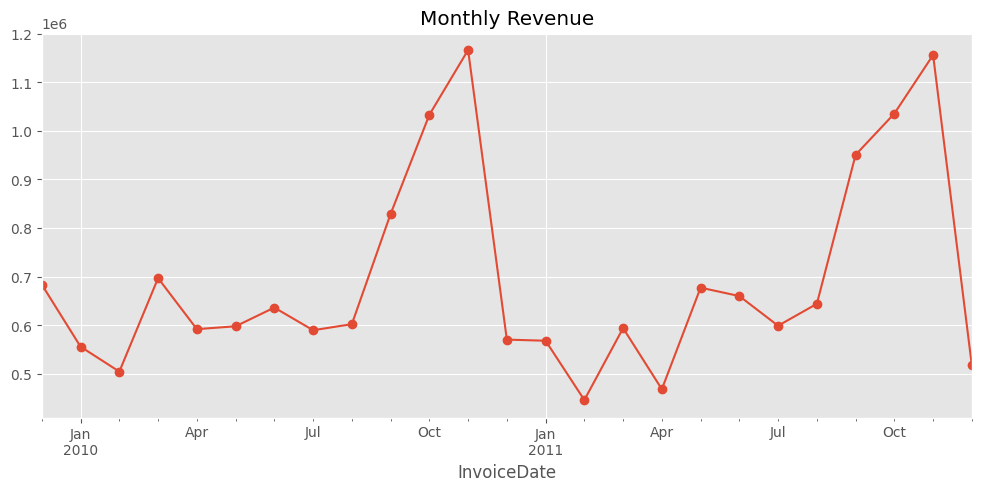

In [14]:
monthly_sales = df.groupby(

    df["InvoiceDate"].dt.to_period("M")

)["Revenue"].sum()

monthly_sales.plot(

    figsize=(12,5),

    marker="o"

)

plt.title("Monthly Revenue")

plt.show()

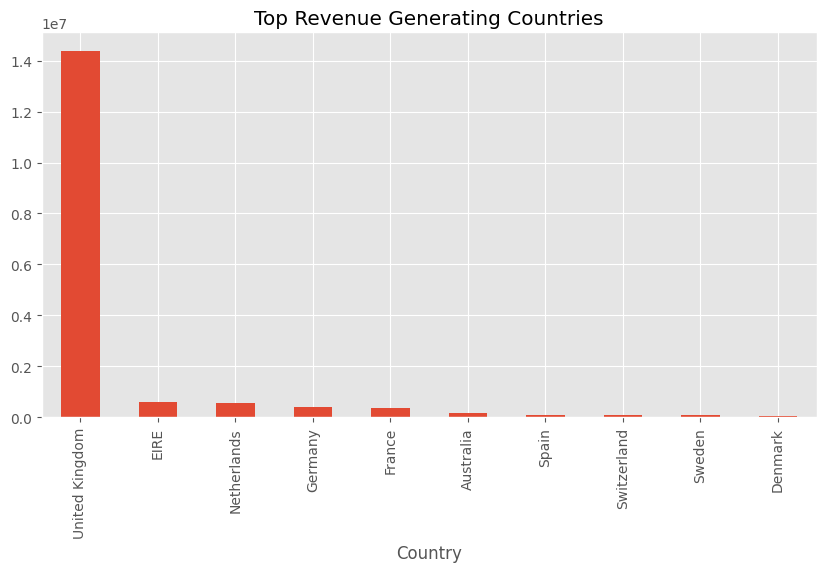

In [15]:
country = df.groupby(

    "Country"

)["Revenue"].sum().sort_values(

    ascending=False

).head(10)

country.plot(

    kind="bar",

    figsize=(10,5)

)

plt.title("Top Revenue Generating Countries")

plt.show()

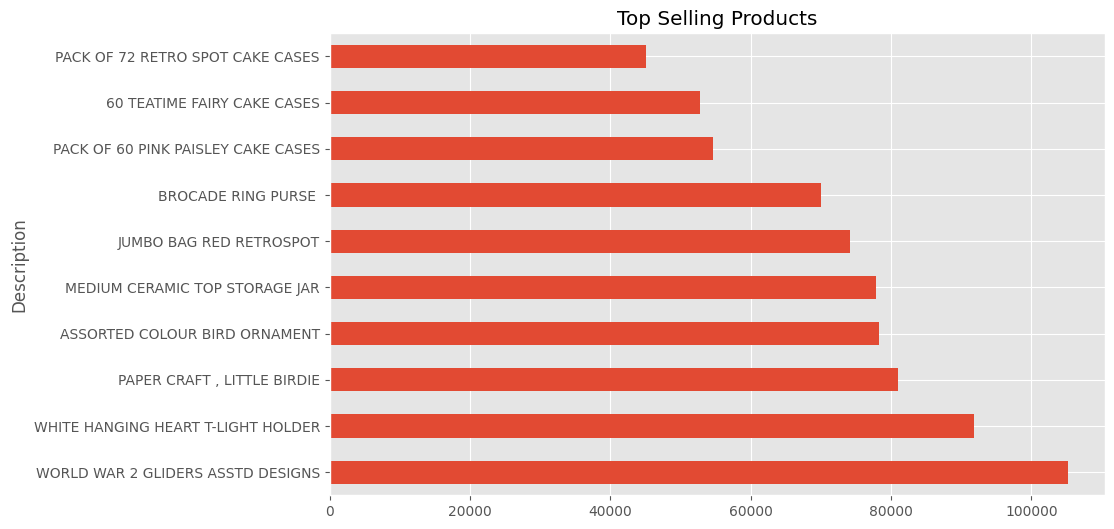

In [16]:
top_products = df.groupby(

    "Description"

)["Quantity"].sum().sort_values(

    ascending=False

).head(10)

top_products.plot(

    kind="barh",

    figsize=(10,6)

)

plt.title("Top Selling Products")

plt.show()

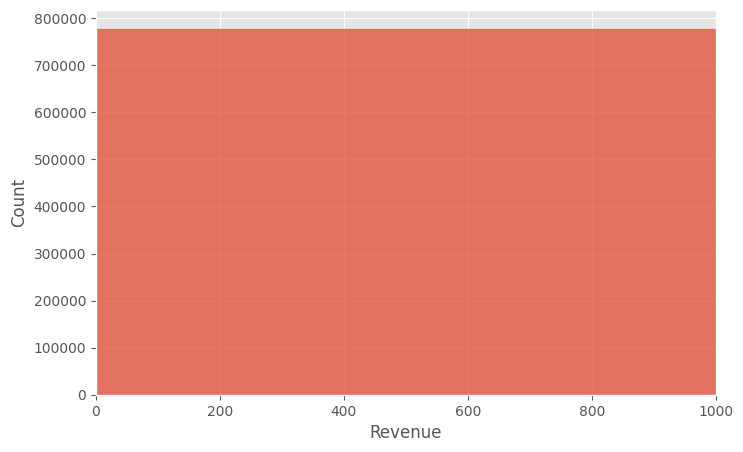

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(

    df["Revenue"],

    bins=100

)

plt.xlim(0,1000)

plt.show()

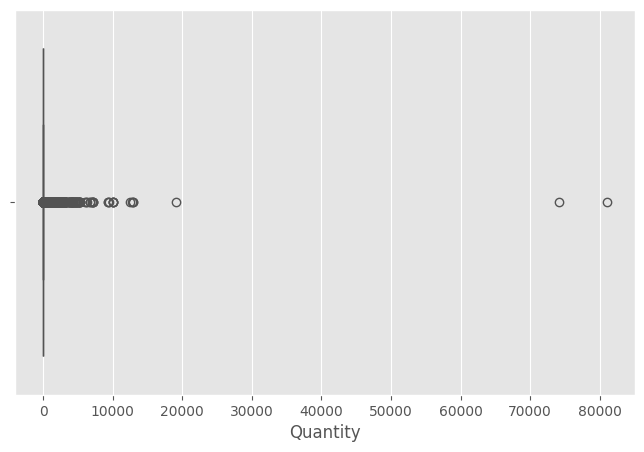

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x=df["Quantity"]

)

plt.show()

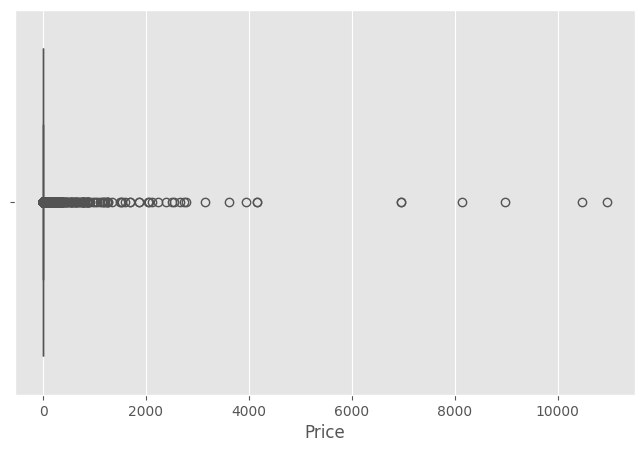

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x=df["Price"]

)

plt.show()

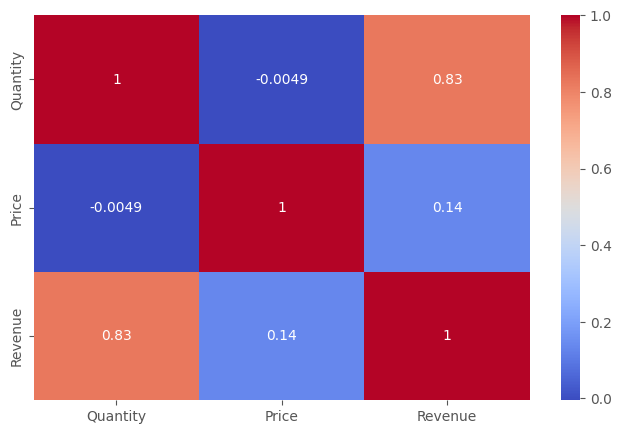

In [20]:
plt.figure(figsize=(8,5))

sns.heatmap(

    df[["Quantity","Price","Revenue"]].corr(),

    annot=True,

    cmap="coolwarm"

)

plt.show()

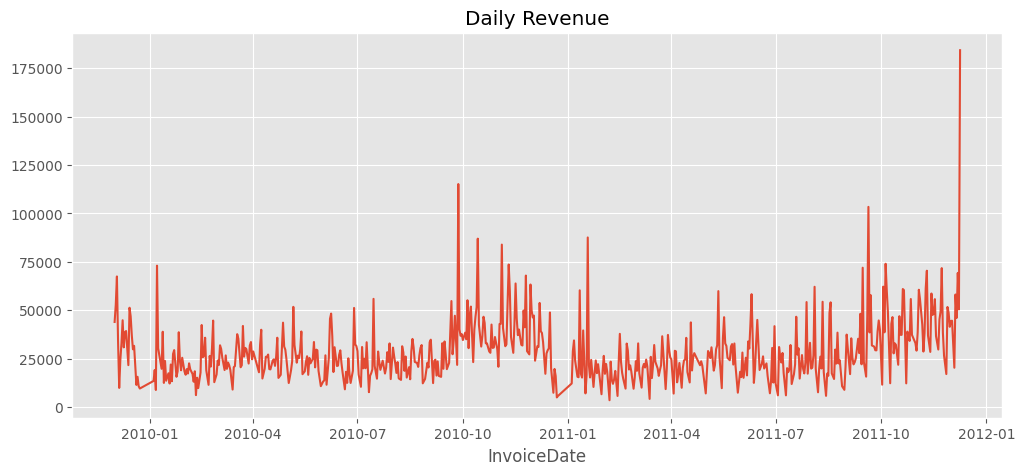

In [21]:
daily = df.groupby(

    df["InvoiceDate"].dt.date

)["Revenue"].sum()

daily.plot(

    figsize=(12,5)

)

plt.title("Daily Revenue")

plt.show()

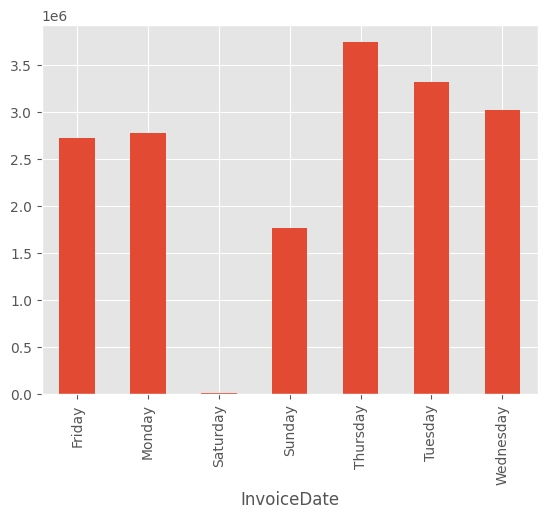

In [22]:
weekday = df.groupby(

    df["InvoiceDate"].dt.day_name()

)["Revenue"].sum()

weekday.plot(

    kind="bar"

)

plt.show()

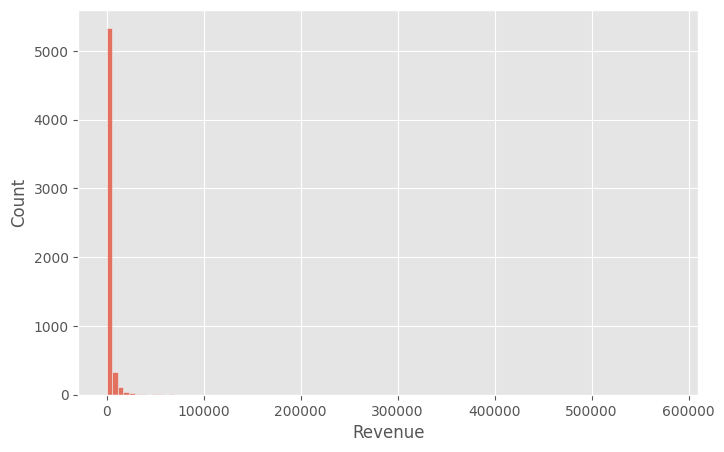

In [23]:
customer_revenue = df.groupby(

    "Customer ID"

)["Revenue"].sum()

plt.figure(figsize=(8,5))

sns.histplot(

    customer_revenue,

    bins=100

)

plt.show()

In [24]:
print(df.describe())

            Quantity                    InvoiceDate          Price  \
count  779425.000000                         779425  779425.000000   
mean       13.489370  2011-01-03 01:44:42.593475584       3.218488   
min         1.000000            2009-12-01 07:45:00       0.001000   
25%         2.000000            2010-07-02 14:39:00       1.250000   
50%         6.000000            2010-12-02 14:09:00       1.950000   
75%        12.000000            2011-08-01 13:44:00       3.750000   
max     80995.000000            2011-12-09 12:50:00   10953.500000   
std       145.855814                            NaN      29.676140   

         Customer ID        Revenue  
count  779425.000000  779425.000000  
mean    15320.360461      22.291823  
min     12346.000000       0.001000  
25%     13971.000000       4.950000  
50%     15247.000000      12.480000  
75%     16794.000000      19.800000  
max     18287.000000  168469.600000  
std      1695.692775     227.427075  


# Feature Engineering

In [25]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [26]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (reference_date - x.max()).days,

    "Invoice": "nunique",

    "Revenue": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [27]:
quantity = df.groupby("Customer ID")["Quantity"].sum()

rfm["TotalQuantity"] = quantity

In [28]:
rfm["AverageQuantity"] = df.groupby(

    "Customer ID"

)["Quantity"].mean()

In [29]:
rfm["MaxQuantity"] = df.groupby(

    "Customer ID"

)["Quantity"].max()

In [30]:
rfm["MinQuantity"] = df.groupby(

    "Customer ID"

)["Quantity"].min()

In [31]:
rfm["AveragePrice"] = df.groupby(

    "Customer ID"

)["Price"].mean()

In [32]:
rfm["MaxPrice"] = df.groupby(

    "Customer ID"

)["Price"].max()

In [33]:
rfm["MinPrice"] = df.groupby(

    "Customer ID"

)["Price"].min()

In [34]:
rfm["AverageOrderValue"] = (

    rfm["Monetary"] /

    rfm["Frequency"]

)

In [35]:
rfm["RevenueStd"] = df.groupby(

    "Customer ID"

)["Revenue"].std()

rfm["RevenueStd"] = rfm["RevenueStd"].fillna(0)

In [36]:
rfm["TotalProducts"] = df.groupby(

    "Customer ID"

)["StockCode"].count()

In [37]:
rfm["UniqueProducts"] = df.groupby(

    "Customer ID"

)["StockCode"].nunique()

In [38]:
rfm["ProductDiversity"] = (

    rfm["UniqueProducts"]

    /

    rfm["TotalProducts"]

)

In [39]:
basket = df.groupby(

    ["Customer ID","Invoice"]

)["Quantity"].sum()

rfm["AverageBasketSize"] = basket.groupby(

    "Customer ID"

).mean()

In [40]:
rfm["MaxBasketSize"] = basket.groupby(

    "Customer ID"

).max()

In [41]:
months = df.groupby(

    "Customer ID"

)["InvoiceDate"].apply(

    lambda x: x.dt.to_period("M").nunique()

)

rfm["ActiveMonths"] = months

In [42]:
lifetime = df.groupby(

    "Customer ID"

)["InvoiceDate"].agg(

    ["min","max"]

)

rfm["CustomerLifetime"] = (

    lifetime["max"]

    -

    lifetime["min"]

).dt.days

In [43]:
purchase_gap = df.groupby("Customer ID")["InvoiceDate"].apply(

    lambda x: x.sort_values().diff().dt.days.mean()

)

rfm["AvgPurchaseGap"] = purchase_gap.fillna(0)

In [44]:
df["Weekend"] = (

    df["InvoiceDate"]

    .dt.dayofweek >=5

).astype(int)

weekend = df.groupby(

    "Customer ID"

)["Weekend"].mean()

rfm["WeekendRatio"] = weekend

In [45]:
df["Hour"] = df["InvoiceDate"].dt.hour

df["Morning"] = (

    df["Hour"]<12

).astype(int)

rfm["MorningRatio"] = df.groupby(

    "Customer ID"

)["Morning"].mean()

In [46]:
df["Afternoon"] = (

    (df["Hour"]>=12)

    &

    (df["Hour"]<18)

).astype(int)

rfm["AfternoonRatio"] = df.groupby(

    "Customer ID"

)["Afternoon"].mean()

In [47]:
df["Evening"] = (

    df["Hour"]>=18

).astype(int)

rfm["EveningRatio"] = df.groupby(

    "Customer ID"

)["Evening"].mean()

In [48]:
country = df.groupby(

    "Customer ID"

)["Country"].agg(

    lambda x: x.mode()[0]

)

rfm["Country"] = country

In [49]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

rfm["Country"] = encoder.fit_transform(

    rfm["Country"]

)

In [50]:
rfm["FrequencyPerMonth"] = (

    rfm["Frequency"]

    /

    rfm["ActiveMonths"]

)

In [51]:
rfm["RevenuePerProduct"] = (

    rfm["Monetary"]

    /

    rfm["TotalProducts"]

)

In [52]:
rfm["CustomerValue"] = (

    rfm["Monetary"]

    *

    rfm["Frequency"]

)

rfm.head()
print(rfm.shape)

(5878, 28)


In [53]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
TotalQuantity,0
AverageQuantity,0
MaxQuantity,0
MinQuantity,0
AveragePrice,0
MaxPrice,0
MinPrice,0


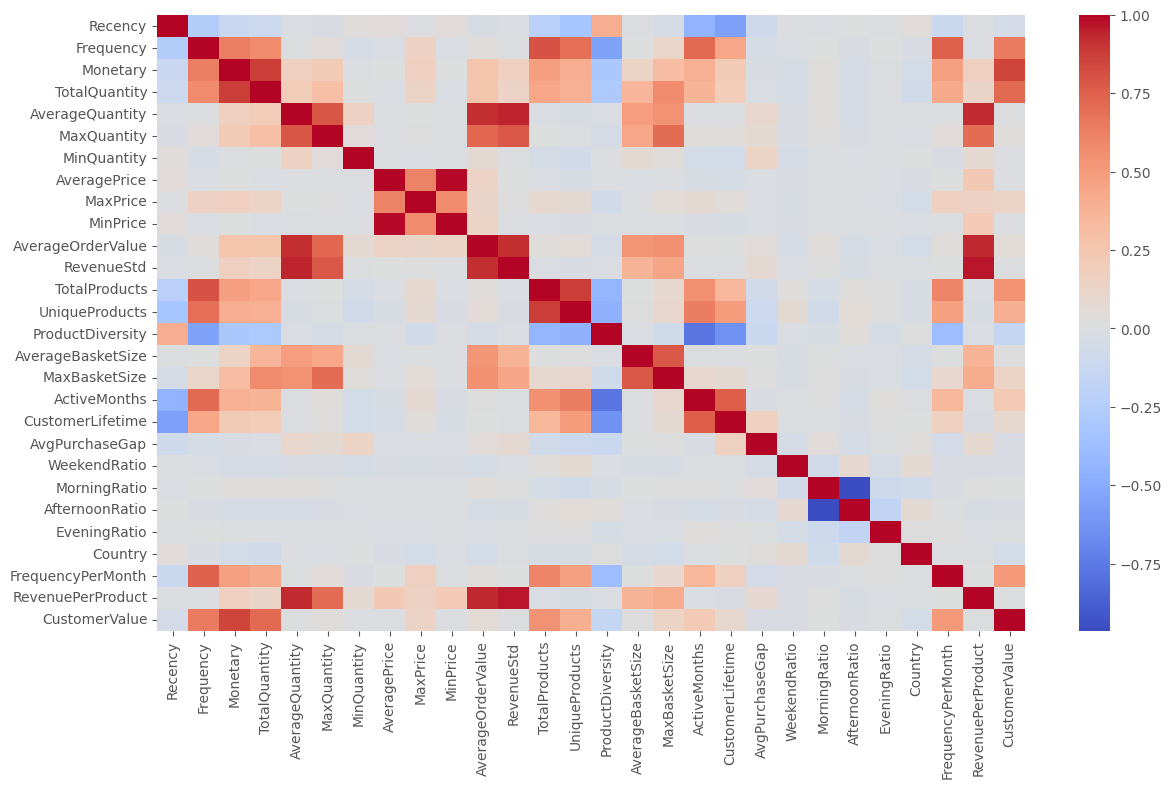

In [54]:
plt.figure(figsize=(14,8))

sns.heatmap(

    rfm.corr(),

    cmap="coolwarm"

)

plt.show()

In [55]:
rfm.to_csv(

    "Customer_Features.csv"

)

print("Customer Features Saved.")

Customer Features Saved.


In [57]:
print(rfm.shape)
rfm.head()

(5878, 28)


,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country,FrequencyPerMonth,RevenuePerProduct,CustomerValue
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,74285,2184.852941,74215,1,6.100000,7.49,1.00,6463.038333,13234.943418,34,27,0.794118,6190.416667,74215,5,400,11.969697,0.000000,0.235294,0.764706,0.000000,38,2.4,2281.072353,930677.52
12347.0,2,8,4921.53,2967,13.364865,240,2,2.498063,12.75,0.25,615.191250,21.467716,222,126,0.567568,370.875000,676,8,402,1.805430,0.180180,0.207207,0.792793,0.000000,16,1.0,22.169054,39372.24
12348.0,75,5,2019.40,2714,53.215686,144,1,3.786275,40.00,0.29,403.880000,44.205549,51,25,0.490196,542.800000,1254,5,362,7.240000,0.058824,0.215686,0.450980,0.333333,12,1.0,39.596078,10097.00
12349.0,19,4,4428.69,1624,9.280000,48,1,8.459657,300.00,0.42,1107.172500,33.761403,175,138,0.788571,406.000000,631,4,570,3.270115,0.000000,0.737143,0.262857,0.000000,18,1.0,25.306800,17714.76
12350.0,310,1,334.40,197,11.588235,24,1,3.841176,40.00,0.85,334.400000,7.275538,17,17,1.000000,197.000000,197,1,0,0.000000,0.000000,0.000000,1.000000,0.000000,26,1.0,19.670588,334.40


In [58]:
# Feature Matrix
X = rfm.copy()

print(X.shape)
X.head()

(5878, 28)


,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country,FrequencyPerMonth,RevenuePerProduct,CustomerValue
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,74285,2184.852941,74215,1,6.100000,7.49,1.00,6463.038333,13234.943418,34,27,0.794118,6190.416667,74215,5,400,11.969697,0.000000,0.235294,0.764706,0.000000,38,2.4,2281.072353,930677.52
12347.0,2,8,4921.53,2967,13.364865,240,2,2.498063,12.75,0.25,615.191250,21.467716,222,126,0.567568,370.875000,676,8,402,1.805430,0.180180,0.207207,0.792793,0.000000,16,1.0,22.169054,39372.24
12348.0,75,5,2019.40,2714,53.215686,144,1,3.786275,40.00,0.29,403.880000,44.205549,51,25,0.490196,542.800000,1254,5,362,7.240000,0.058824,0.215686,0.450980,0.333333,12,1.0,39.596078,10097.00
12349.0,19,4,4428.69,1624,9.280000,48,1,8.459657,300.00,0.42,1107.172500,33.761403,175,138,0.788571,406.000000,631,4,570,3.270115,0.000000,0.737143,0.262857,0.000000,18,1.0,25.306800,17714.76
12350.0,310,1,334.40,197,11.588235,24,1,3.841176,40.00,0.85,334.400000,7.275538,17,17,1.000000,197.000000,197,1,0,0.000000,0.000000,0.000000,1.000000,0.000000,26,1.0,19.670588,334.40


In [59]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [60]:
drop_cols = [
    "CustomerValue",
    "RevenuePerProduct",
    "FrequencyPerMonth"
]

existing_cols = [col for col in drop_cols if col in rfm.columns]

rfm = rfm.drop(columns=existing_cols)

print("Removed Columns:")
print(existing_cols)

Removed Columns:
['CustomerValue', 'RevenuePerProduct', 'FrequencyPerMonth']


In [61]:
X = rfm.copy()

print(X.shape)

X.head()

(5878, 25)


,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,74285,2184.852941,74215,1,6.100000,7.49,1.00,6463.038333,13234.943418,34,27,0.794118,6190.416667,74215,5,400,11.969697,0.000000,0.235294,0.764706,0.000000,38
12347.0,2,8,4921.53,2967,13.364865,240,2,2.498063,12.75,0.25,615.191250,21.467716,222,126,0.567568,370.875000,676,8,402,1.805430,0.180180,0.207207,0.792793,0.000000,16
12348.0,75,5,2019.40,2714,53.215686,144,1,3.786275,40.00,0.29,403.880000,44.205549,51,25,0.490196,542.800000,1254,5,362,7.240000,0.058824,0.215686,0.450980,0.333333,12
12349.0,19,4,4428.69,1624,9.280000,48,1,8.459657,300.00,0.42,1107.172500,33.761403,175,138,0.788571,406.000000,631,4,570,3.270115,0.000000,0.737143,0.262857,0.000000,18
12350.0,310,1,334.40,197,11.588235,24,1,3.841176,40.00,0.85,334.400000,7.275538,17,17,1.000000,197.000000,197,1,0,0.000000,0.000000,0.000000,1.000000,0.000000,26


In [62]:
X = rfm.copy()

print(X.shape)

(5878, 25)


In [63]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [64]:
scaled_df = pd.DataFrame(

    X_scaled,

    columns=X.columns,

    index=X.index

)

scaled_df.head()

,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,0.595584,0.438998,5.166378,8.168099,5.915978,49.887133,-0.103968,-0.014072,-0.098440,-0.022933,5.005717,10.037783,-0.288170,-0.472112,-0.180343,4.172302,28.455092,0.143675,0.490667,0.394375,-0.524574,-0.247518,0.294747,-0.186819,0.278206
12347.0,-0.952279,0.131502,0.136127,0.132759,-0.032748,0.079053,-0.083459,-0.034503,-0.081082,-0.027273,0.189436,-0.018161,0.261279,0.377858,-1.380885,0.086578,0.079037,0.811281,0.498395,-0.192106,0.128795,-0.328277,0.374734,-0.186819,-3.066265
12348.0,-0.603532,-0.099120,-0.064857,0.104253,0.076422,0.014415,-0.103968,-0.027196,0.008847,-0.027041,0.015401,-0.000857,-0.238485,-0.489283,-1.790894,0.207281,0.302067,0.143675,0.343827,0.121470,-0.311269,-0.303897,-0.598687,3.388808,-3.674350
12349.0,-0.871064,-0.175994,0.101996,-0.018556,-0.043939,-0.050223,-0.103968,-0.000688,0.866882,-0.026289,0.594632,-0.008805,0.123917,0.480885,-0.209733,0.111238,0.061673,-0.078860,1.147582,-0.107593,-0.524574,1.195463,-1.134429,-0.186819,-2.762222
12350.0,0.519146,-0.406616,-0.181549,-0.179335,-0.037616,-0.066382,-0.103968,-0.026885,0.008847,-0.023801,-0.041823,-0.028962,-0.337854,-0.557968,0.910676,-0.035494,-0.105792,-0.746466,-1.055014,-0.296280,-0.524574,-0.924066,0.964823,-0.186819,-1.546051


# PCA & K-Means Clustering

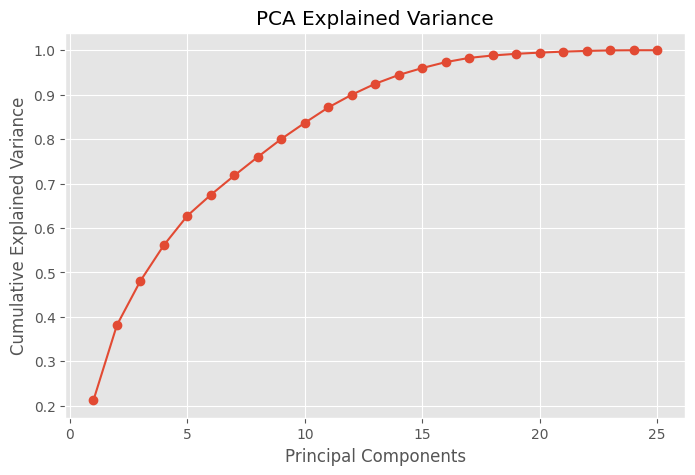

Optimal Components : 15


In [70]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

cum_var = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

optimal_components = np.argmax(cum_var>=0.95)+1

print("Optimal Components :",optimal_components)

In [74]:
optimal_components = np.argmax(cum_var >= 0.95) + 1

print("Optimal Components:", optimal_components)

Optimal Components: 15


In [75]:
pca_cluster = PCA(n_components=optimal_components)

X_cluster = pca_cluster.fit_transform(X_scaled)

In [76]:
pca_visual = PCA(n_components=2)

X_pca = pca_visual.fit_transform(X_scaled)

In [77]:
pca_df = pd.DataFrame(

    X_pca,

    columns=["PC1","PC2"],

    index=rfm.index

)

pca_df.head()

,PC1,PC2
Customer ID,,
12346.0,28.046782,32.574654
12347.0,1.330872,-0.823783
12348.0,0.733548,-0.220088
12349.0,0.917064,-0.211133
12350.0,-1.358618,0.875352


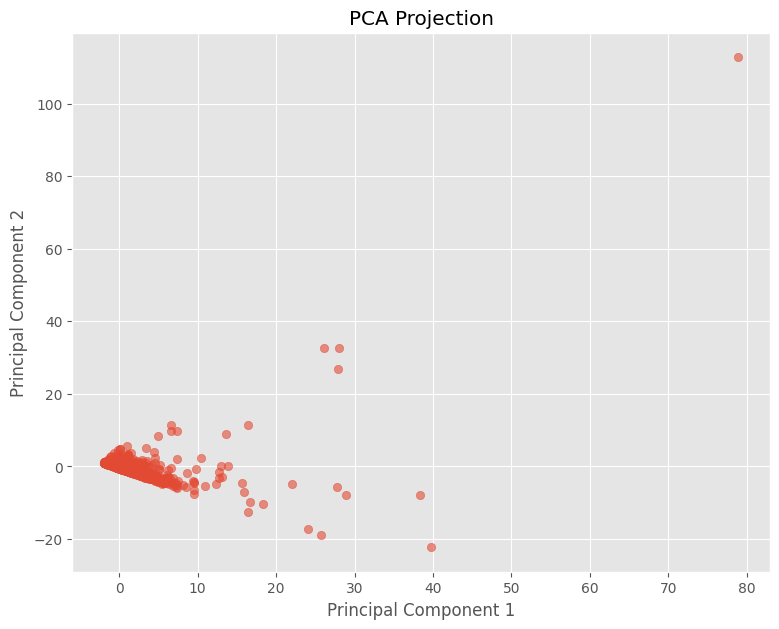

In [78]:
plt.figure(figsize=(9,7))

plt.scatter(

    pca_df["PC1"],

    pca_df["PC2"],

    alpha=0.6

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Projection")

plt.show()

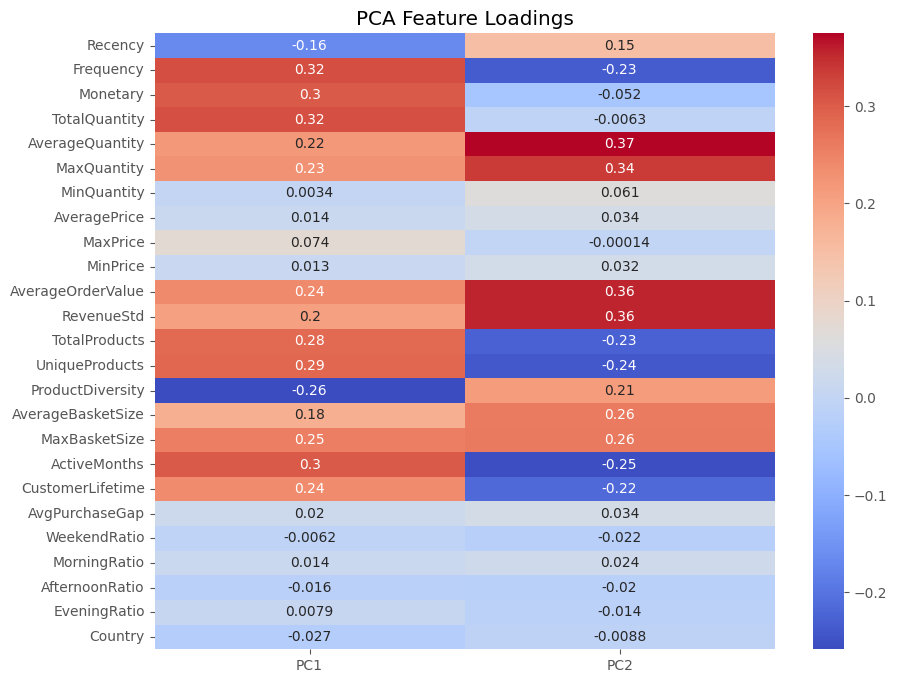

In [79]:
loadings = pd.DataFrame(

    pca_visual.components_.T,

    columns=["PC1","PC2"],

    index=X.columns

)

plt.figure(figsize=(10,8))

sns.heatmap(

    loadings,

    annot=True,

    cmap="coolwarm"

)

plt.title("PCA Feature Loadings")

plt.show()

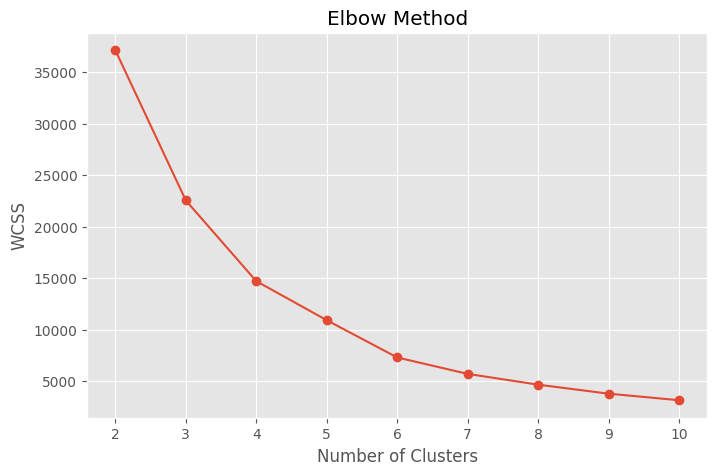

In [81]:
wcss = []

for k in range(2,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(X_pca)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    wcss,

    marker="o"

)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

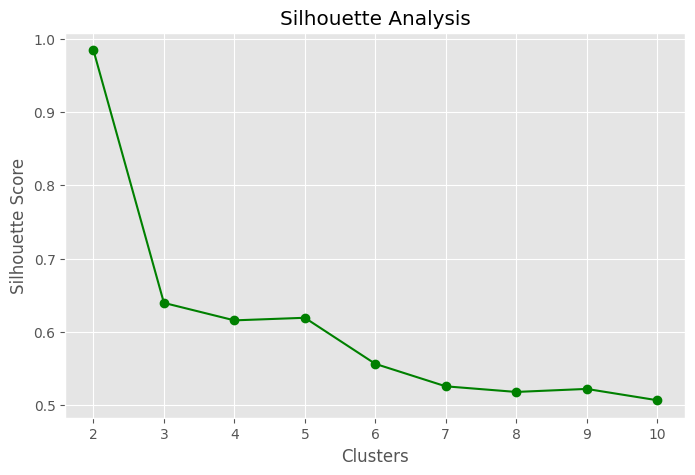

In [82]:
scores = []

for k in range(2,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(X_pca)

    score = silhouette_score(

        X_pca,

        labels

    )

    scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(

    range(2,11),

    scores,

    marker="o",

    color="green"

)

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [83]:
best_k = 4

print("Chosen Number of Clusters :",best_k)

print()

print("Reason:")

print("""
Silhouette Score suggested K=2.
However, Elbow Method indicated K≈4.

Since customer segmentation should generate
meaningful business personas rather than only
maximize the clustering metric,
K=4 was selected.
""")

Chosen Number of Clusters : 4

Reason:

Silhouette Score suggested K=2.
However, Elbow Method indicated K≈4.

Since customer segmentation should generate
meaningful business personas rather than only
maximize the clustering metric,
K=4 was selected.



In [84]:
kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10

)

clusters = kmeans.fit_predict(X_cluster)

In [85]:
rfm["Cluster"] = clusters

pca_df["Cluster"] = clusters

rfm.head()

,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country,Cluster
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,74285,2184.852941,74215,1,6.100000,7.49,1.00,6463.038333,13234.943418,34,27,0.794118,6190.416667,74215,5,400,11.969697,0.000000,0.235294,0.764706,0.000000,38,2
12347.0,2,8,4921.53,2967,13.364865,240,2,2.498063,12.75,0.25,615.191250,21.467716,222,126,0.567568,370.875000,676,8,402,1.805430,0.180180,0.207207,0.792793,0.000000,16,0
12348.0,75,5,2019.40,2714,53.215686,144,1,3.786275,40.00,0.29,403.880000,44.205549,51,25,0.490196,542.800000,1254,5,362,7.240000,0.058824,0.215686,0.450980,0.333333,12,0
12349.0,19,4,4428.69,1624,9.280000,48,1,8.459657,300.00,0.42,1107.172500,33.761403,175,138,0.788571,406.000000,631,4,570,3.270115,0.000000,0.737143,0.262857,0.000000,18,0
12350.0,310,1,334.40,197,11.588235,24,1,3.841176,40.00,0.85,334.400000,7.275538,17,17,1.000000,197.000000,197,1,0,0.000000,0.000000,0.000000,1.000000,0.000000,26,1


Cluster
1    4061
0    1793
2      23
3       1
Name: count, dtype: int64


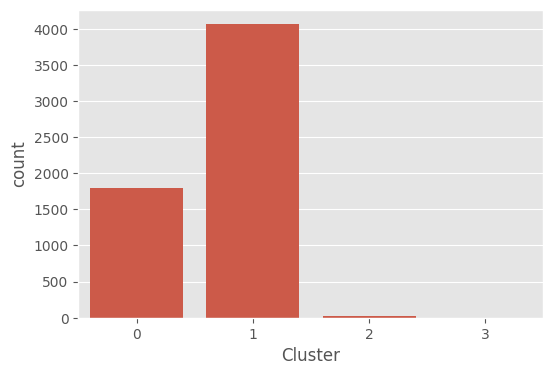

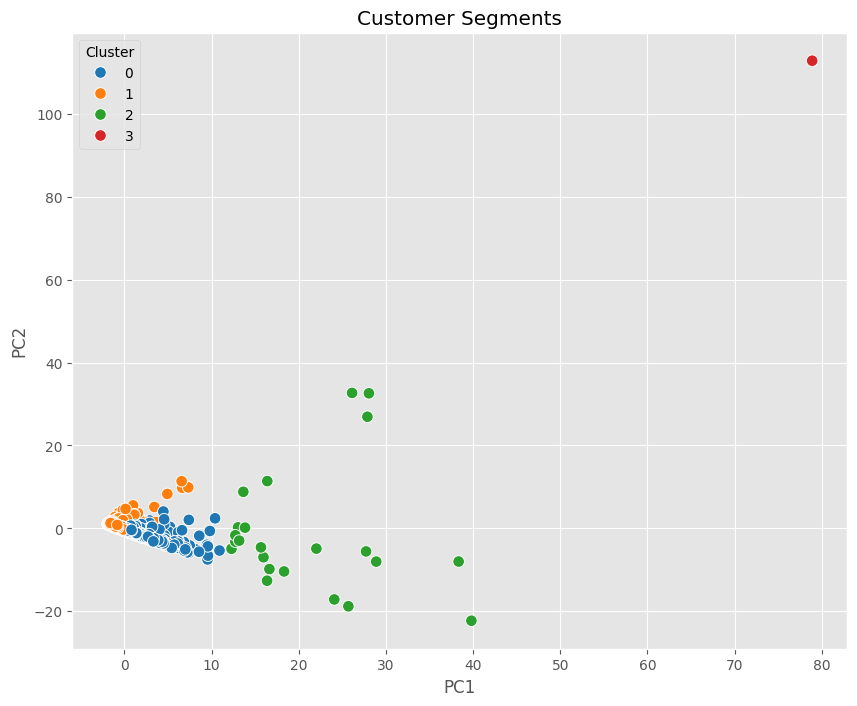

In [86]:
print(rfm["Cluster"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(

    x="Cluster",

    data=rfm

)

plt.show()
plt.figure(figsize=(10,8))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="tab10",

    s=70

)

plt.title("Customer Segments")

plt.show()

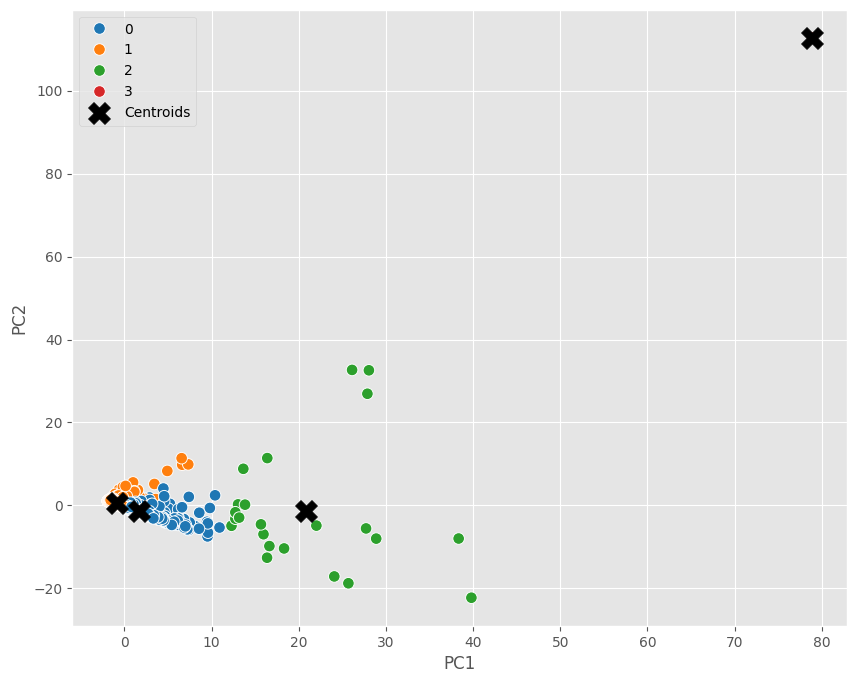

In [87]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(10,8))

sns.scatterplot(

    data=pca_df,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="tab10",

    s=70

)

plt.scatter(

    centers[:,0],

    centers[:,1],

    marker="X",

    s=250,

    c="black",

    label="Centroids"

)

plt.legend()

plt.show()

In [88]:
pca3 = PCA(n_components=3)

X_pca3 = pca3.fit_transform(X_scaled)

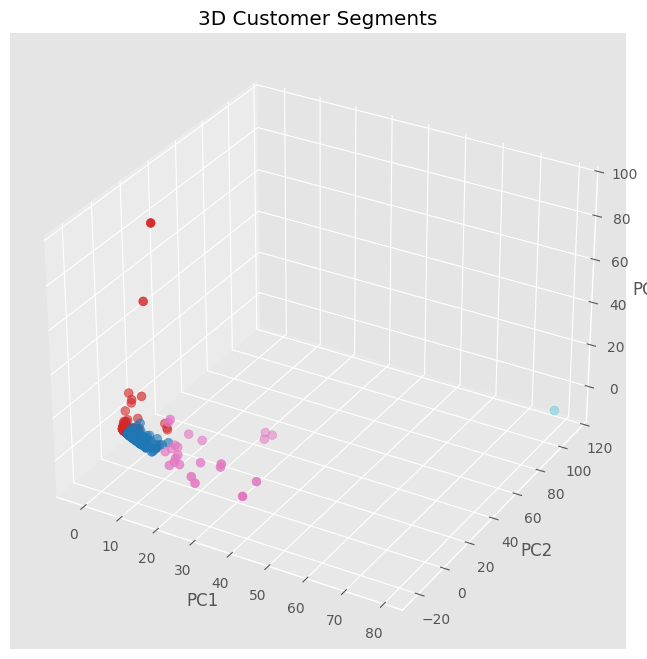

In [89]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(

    X_pca3[:,0],

    X_pca3[:,1],

    X_pca3[:,2],

    c=clusters,

    cmap="tab10",

    s=40

)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D Customer Segments")

plt.show()

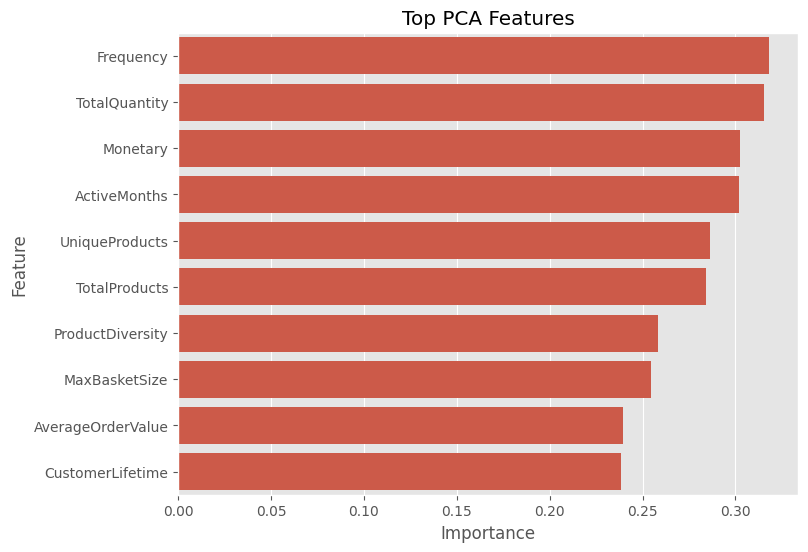

In [90]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":abs(loadings["PC1"])

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

plt.figure(figsize=(8,6))

sns.barplot(

    data=importance.head(10),

    y="Feature",

    x="Importance"

)

plt.title("Top PCA Features")

plt.show()

In [91]:
cluster_summary = rfm.groupby("Cluster").mean().round(2)

cluster_summary

,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,
0,52.31,13.64,5775.94,3385.60,21.27,149.11,3.68,3.23,41.88,0.33,412.54,27.96,294.62,166.62,0.63,246.02,601.32,9.29,569.51,6.45,0.15,0.32,0.66,0.02,36.10
1,267.93,2.39,794.72,455.89,17.67,57.66,7.13,10.94,29.18,7.04,339.36,24.48,46.26,40.87,0.92,197.42,270.02,2.09,140.11,4.55,0.14,0.32,0.66,0.02,36.23
2,68.57,122.35,157509.77,109183.39,519.41,6004.48,4.48,8.69,1119.79,0.21,2697.47,853.83,2752.13,747.57,0.41,7469.28,22340.13,19.30,630.83,2.07,0.06,0.37,0.60,0.02,30.96
3,1.00,2.00,168472.50,80997.00,26999.00,80995.00,1.00,1.66,2.08,1.25,84236.25,97265.13,3.00,3.00,1.00,40498.50,80995.00,2.00,204.00,102.00,0.00,1.00,0.00,0.00,38.00


In [93]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    pca_cluster,
    "pca.pkl"
)

joblib.dump(
    kmeans,
    "kmeans.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


# Business Personas, Insights & Final Report

In [94]:
cluster_summary = rfm.groupby("Cluster").agg({

    "Recency":"mean",

    "Frequency":"mean",

    "Monetary":"mean",

    "AverageOrderValue":"mean",

    "AverageBasketSize":"mean",

    "ProductDiversity":"mean"

}).round(2)

cluster_summary

,Recency,Frequency,Monetary,AverageOrderValue,AverageBasketSize,ProductDiversity
Cluster,,,,,,
0,52.31,13.64,5775.94,412.54,246.02,0.63
1,267.93,2.39,794.72,339.36,197.42,0.92
2,68.57,122.35,157509.77,2697.47,7469.28,0.41
3,1.00,2.00,168472.50,84236.25,40498.50,1.00


In [95]:
cluster_size = rfm["Cluster"].value_counts().sort_index()

print(cluster_size)

Cluster
0    1793
1    4061
2      23
3       1
Name: count, dtype: int64


In [96]:
premium = cluster_summary["Monetary"].idxmax()

dormant = cluster_summary["Recency"].idxmax()

frequent = cluster_summary["Frequency"].idxmax()

low_value = cluster_summary["Monetary"].idxmin()

persona = {}

for cluster in cluster_summary.index:

    if cluster == premium:

        persona[cluster] = "Premium Loyal Customers"

    elif cluster == dormant:

        persona[cluster] = "Dormant Customers"

    elif cluster == frequent:

        persona[cluster] = "Frequent Buyers"

    elif cluster == low_value:

        persona[cluster] = "Low Value Customers"

    else:

        persona[cluster] = "Regular Customers"

rfm["Persona"] = rfm["Cluster"].map(persona)

rfm.head()

,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country,Cluster,Persona
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
12346.0,326,12,77556.46,74285,2184.852941,74215,1,6.100000,7.49,1.00,6463.038333,13234.943418,34,27,0.794118,6190.416667,74215,5,400,11.969697,0.000000,0.235294,0.764706,0.000000,38,2,Frequent Buyers
12347.0,2,8,4921.53,2967,13.364865,240,2,2.498063,12.75,0.25,615.191250,21.467716,222,126,0.567568,370.875000,676,8,402,1.805430,0.180180,0.207207,0.792793,0.000000,16,0,Regular Customers
12348.0,75,5,2019.40,2714,53.215686,144,1,3.786275,40.00,0.29,403.880000,44.205549,51,25,0.490196,542.800000,1254,5,362,7.240000,0.058824,0.215686,0.450980,0.333333,12,0,Regular Customers
12349.0,19,4,4428.69,1624,9.280000,48,1,8.459657,300.00,0.42,1107.172500,33.761403,175,138,0.788571,406.000000,631,4,570,3.270115,0.000000,0.737143,0.262857,0.000000,18,0,Regular Customers
12350.0,310,1,334.40,197,11.588235,24,1,3.841176,40.00,0.85,334.400000,7.275538,17,17,1.000000,197.000000,197,1,0,0.000000,0.000000,0.000000,1.000000,0.000000,26,1,Dormant Customers


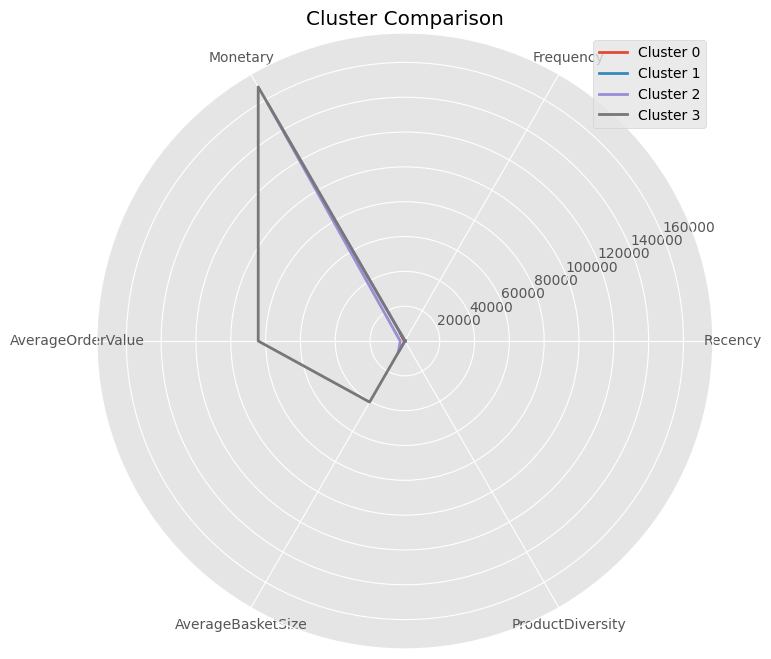

In [97]:
from math import pi

radar = cluster_summary.copy()

categories = radar.columns.tolist()

N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]

angles += angles[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

for i in radar.index:

    values = radar.loc[i].tolist()

    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=f"Cluster {i}")

plt.xticks(angles[:-1], categories)

plt.legend()

plt.title("Cluster Comparison")

plt.show()

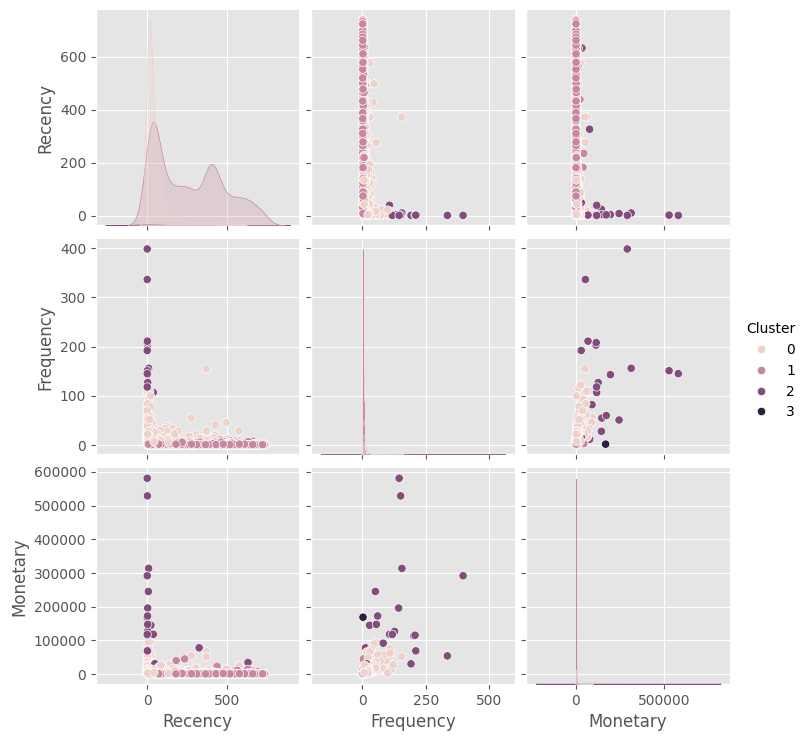

In [98]:
sns.pairplot(

    rfm,

    vars=[

        "Recency",

        "Frequency",

        "Monetary"

    ],

    hue="Cluster"

)

In [99]:
for cluster in sorted(rfm["Cluster"].unique()):

    print("="*70)

    print("Cluster :",cluster)

    temp = rfm[rfm["Cluster"]==cluster]

    print("Customers :",len(temp))

    print("Average Recency :",round(temp["Recency"].mean(),2))

    print("Average Frequency :",round(temp["Frequency"].mean(),2))

    print("Average Monetary :",round(temp["Monetary"].mean(),2))

    print("Average Basket Size :",round(temp["AverageBasketSize"].mean(),2))

Cluster : 0
Customers : 1793
Average Recency : 52.31
Average Frequency : 13.64
Average Monetary : 5775.94
Average Basket Size : 246.02
Cluster : 1
Customers : 4061
Average Recency : 267.93
Average Frequency : 2.39
Average Monetary : 794.72
Average Basket Size : 197.42
Cluster : 2
Customers : 23
Average Recency : 68.57
Average Frequency : 122.35
Average Monetary : 157509.77
Average Basket Size : 7469.28
Cluster : 3
Customers : 1
Average Recency : 1.0
Average Frequency : 2.0
Average Monetary : 168472.5
Average Basket Size : 40498.5


In [100]:
print("="*80)
print("CUSTOMER SEGMENTATION BUSINESS INSIGHTS")
print("="*80)

for persona in sorted(rfm["Persona"].unique()):

    temp = rfm[rfm["Persona"] == persona]

    print("\n" + "="*80)
    print(f"PERSONA: {persona}")
    print("="*80)

    print(f"Number of Customers        : {len(temp)}")
    print(f"Average Revenue            : ${temp['Monetary'].mean():,.2f}")
    print(f"Median Revenue             : ${temp['Monetary'].median():,.2f}")
    print(f"Average Purchase Frequency : {temp['Frequency'].mean():.2f}")
    print(f"Average Recency            : {temp['Recency'].mean():.2f} days")
    print(f"Average Basket Size        : {temp['AverageBasketSize'].mean():.2f}")
    print(f"Average Order Value        : ${temp['AverageOrderValue'].mean():,.2f}")
    print(f"Average Product Diversity  : {temp['ProductDiversity'].mean():.2f}")

    print("\nBusiness Interpretation:")

    if persona == "Premium Loyal Customers":

        print("- Highest revenue generating customers.")
        print("- Purchase frequently and recently.")
        print("- High lifetime value.")
        print("- Strong brand loyalty.")

        print("\nRecommendation:")
        print("- VIP Membership")
        print("- Exclusive launches")
        print("- Premium customer support")
        print("- Personalized recommendations")

    elif persona == "Frequent Buyers":

        print("- Shop regularly.")
        print("- Moderate-to-high spending.")
        print("- Good retention potential.")

        print("\nRecommendation:")
        print("- Loyalty rewards")
        print("- Subscription plans")
        print("- Product bundles")
        print("- Referral bonuses")

    elif persona == "Dormant Customers":

        print("- Long time since last purchase.")
        print("- Low shopping frequency.")
        print("- High churn risk.")

        print("\nRecommendation:")
        print("- Win-back campaigns")
        print("- Personalized email offers")
        print("- Limited-time discounts")
        print("- Feedback surveys")

    elif persona == "Low Value Customers":

        print("- Low revenue contribution.")
        print("- Small basket sizes.")
        print("- Infrequent purchases.")

        print("\nRecommendation:")
        print("- Coupons")
        print("- Cross-selling")
        print("- Bundle offers")
        print("- First purchase incentives")

    else:

        print("- Average customer behaviour.")
        print("- Stable purchasing habits.")
        print("- Opportunity for upselling.")

        print("\nRecommendation:")
        print("- Personalized marketing")
        print("- Seasonal promotions")
        print("- Cross-selling")
        print("- Loyalty program")

CUSTOMER SEGMENTATION BUSINESS INSIGHTS

PERSONA: Dormant Customers
Number of Customers        : 4061
Average Revenue            : $794.72
Median Revenue             : $496.00
Average Purchase Frequency : 2.39
Average Recency            : 267.93 days
Average Basket Size        : 197.42
Average Order Value        : $339.36
Average Product Diversity  : 0.92

Business Interpretation:
- Long time since last purchase.
- Low shopping frequency.
- High churn risk.

Recommendation:
- Win-back campaigns
- Personalized email offers
- Limited-time discounts
- Feedback surveys

PERSONA: Frequent Buyers
Number of Customers        : 23
Average Revenue            : $157,509.77
Median Revenue             : $117,314.08
Average Purchase Frequency : 122.35
Average Recency            : 68.57 days
Average Basket Size        : 7469.28
Average Order Value        : $2,697.47
Average Product Diversity  : 0.41

Business Interpretation:
- Shop regularly.
- Moderate-to-high spending.
- Good retention potential.



In [101]:
print("="*80)
print("OVERALL BUSINESS SUMMARY")
print("="*80)

print(f"Total Customers            : {len(rfm):,}")
print(f"Total Revenue              : ${rfm['Monetary'].sum():,.2f}")
print(f"Average Customer Revenue   : ${rfm['Monetary'].mean():,.2f}")
print(f"Average Purchase Frequency : {rfm['Frequency'].mean():.2f}")
print(f"Average Basket Size        : {rfm['AverageBasketSize'].mean():.2f}")
print(f"Average Order Value        : ${rfm['AverageOrderValue'].mean():,.2f}")

OVERALL BUSINESS SUMMARY
Total Customers            : 5,878
Total Revenue              : $17,374,804.27
Average Customer Revenue   : $2,955.90
Average Purchase Frequency : 6.29
Average Basket Size        : 247.56
Average Order Value        : $385.18


# Business Conclusion

Based on customer purchase behaviour, the K-Means clustering model successfully segmented customers into distinct groups with similar shopping patterns.

### Key Findings

- Premium Loyal Customers contribute the highest revenue and should be retained through loyalty programs.
- Frequent Buyers show strong engagement and are ideal targets for upselling and referral campaigns.
- Dormant Customers have high churn risk and should receive personalized win-back campaigns.
- Low Value Customers can be encouraged to spend more using coupons and product bundles.
- Regular Customers represent growth opportunities through personalized marketing.

### Business Impact

This customer segmentation framework enables businesses to:

- Improve customer retention
- Increase revenue through targeted marketing
- Optimize promotional campaigns
- Personalize customer experiences
- Enhance strategic decision-making using data-driven customer insights

In [102]:
export = rfm[[

    "Cluster",

    "Persona",

    "Recency",

    "Frequency",

    "Monetary",

    "AverageOrderValue"

]]

export.to_csv(

    "Customer_Segments_Final.csv"

)

print("Exported Successfully")

Exported Successfully


In [103]:
top_customers = rfm.sort_values(

    "Monetary",

    ascending=False

).head(10)

top_customers

,Recency,Frequency,Monetary,TotalQuantity,AverageQuantity,MaxQuantity,MinQuantity,AveragePrice,MaxPrice,MinPrice,AverageOrderValue,RevenueStd,TotalProducts,UniqueProducts,ProductDiversity,AverageBasketSize,MaxBasketSize,ActiveMonths,CustomerLifetime,AvgPurchaseGap,WeekendRatio,MorningRatio,AfternoonRatio,EveningRatio,Country,Cluster,Persona
Customer ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
18102.0,1,145,580987.04,181645,174.658654,1008,1,3.794740,52.78,0.27,4006.807172,602.882230,1040,382,0.367308,1252.724138,7782,23,738,0.674687,0.016346,0.442308,0.453846,0.103846,38,2,Frequent Buyers
14646.0,2,151,528602.52,367193,95.399584,2400,1,2.451567,295.00,0.19,3500.678940,163.177280,3849,961,0.249675,2431.741722,14730,25,735,0.178534,0.026760,0.482203,0.517797,0.000000,24,2,Frequent Buyers
14156.0,10,156,313437.62,164325,40.694651,1440,1,5.949911,2736.16,0.04,2009.215513,169.799181,4038,1446,0.358098,1053.365385,25018,24,728,0.164479,0.068351,0.329371,0.662209,0.008420,10,2,Frequent Buyers
14911.0,1,398,291420.81,147972,13.358491,640,1,5.135474,1687.17,0.04,732.213090,42.880042,11077,2550,0.230207,371.788945,4462,25,737,0.052727,0.083777,0.400831,0.581024,0.018146,10,2,Frequent Buyers
17450.0,8,51,244784.25,83914,199.795238,1944,4,3.322452,12.98,0.55,4799.691176,872.010573,420,144,0.342857,1645.372549,12572,14,429,0.990453,0.000000,0.492857,0.354762,0.152381,38,2,Frequent Buyers
13694.0,4,143,195640.69,188201,123.897959,1600,2,1.664937,12.75,0.04,1368.116713,106.578632,1519,896,0.589862,1316.090909,20524,25,731,0.452569,0.026991,0.408163,0.571429,0.020408,38,2,Frequent Buyers
17511.0,3,60,172132.87,117174,62.726981,600,1,2.399786,39.95,0.10,2868.881167,85.778229,1868,657,0.351713,1952.900000,4675,25,734,0.377076,0.000000,0.638651,0.361349,0.000000,38,2,Frequent Buyers
16446.0,1,2,168472.50,80997,26999.000000,80995,1,1.660000,2.08,1.25,84236.250000,97265.131753,3,3,1.000000,40498.500000,80995,2,204,102.000000,0.000000,1.000000,0.000000,0.000000,38,3,Premium Loyal Customers
16684.0,4,55,147142.77,104810,145.974930,1152,3,2.582688,12.75,0.25,2675.323091,215.205802,718,184,0.256267,1905.636364,10014,18,728,0.994421,0.137883,0.477716,0.522284,0.000000,38,2,Frequent Buyers


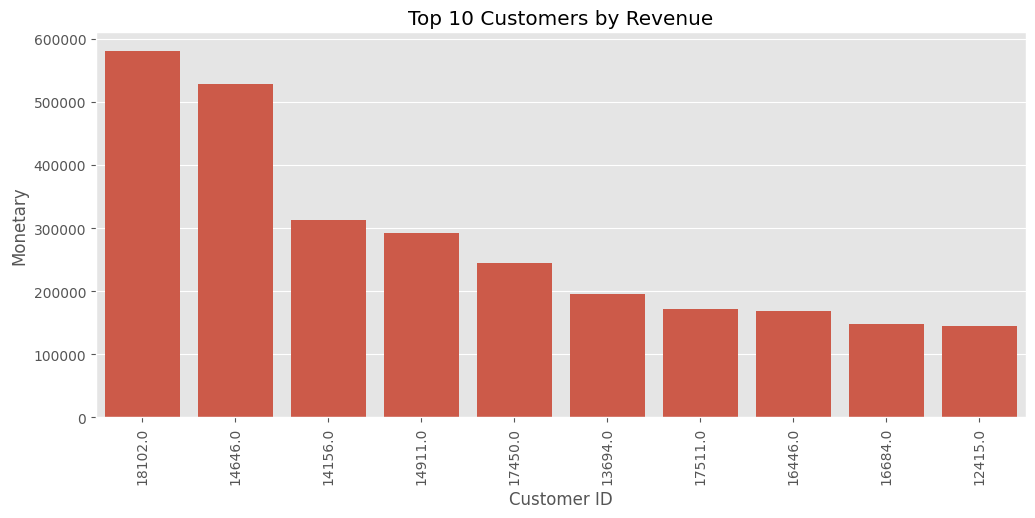

In [104]:
plt.figure(figsize=(12,5))

sns.barplot(

    x=top_customers.index.astype(str),

    y=top_customers["Monetary"]

)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by Revenue")

plt.show()

In [106]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "standard_scaler.pkl")
joblib.dump(pca_cluster, "pca_model.pkl")

['pca_model.pkl']

In [107]:
print("""

CONCLUSION

This project successfully segmented customers using an end-to-end
unsupervised machine learning pipeline.

Key achievements:

• Cleaned and preprocessed transactional retail data.
• Engineered more than 25 customer-level behavioral features.
• Applied PCA to reduce dimensionality while preserving most of the variance.
• Determined the optimal number of clusters using both the Elbow Method and Silhouette Score.
• Built a K-Means clustering model to identify meaningful customer groups.
• Created business personas and actionable marketing recommendations.

The resulting customer segments can help businesses improve
customer retention, targeted marketing, personalized promotions,
and strategic decision-making.

""")



CONCLUSION

This project successfully segmented customers using an end-to-end
unsupervised machine learning pipeline.

Key achievements:

• Cleaned and preprocessed transactional retail data.
• Engineered more than 25 customer-level behavioral features.
• Applied PCA to reduce dimensionality while preserving most of the variance.
• Determined the optimal number of clusters using both the Elbow Method and Silhouette Score.
• Built a K-Means clustering model to identify meaningful customer groups.
• Created business personas and actionable marketing recommendations.

The resulting customer segments can help businesses improve
customer retention, targeted marketing, personalized promotions,
and strategic decision-making.




In [108]:
agg_dict = {
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median"],
    "AverageOrderValue": ["mean"],
    "AverageBasketSize": ["mean"],
    "ProductDiversity": ["mean"]
}

agg_dict = {k: v for k, v in agg_dict.items() if k in rfm.columns}

cluster_summary = rfm.groupby("Cluster").agg(agg_dict).round(2)

cluster_summary

Recency        Frequency          Monetary             \
           mean median      mean median       mean     median   
Cluster                                                         
0         52.31   26.0     13.64   10.0    5775.94    3444.39   
1        267.93  241.0      2.39    2.0     794.72     496.00   
2         68.57    4.0    122.35  118.0  157509.77  117314.08   
3          1.00    1.0      2.00    2.0  168472.50  168472.50   

        AverageOrderValue AverageBasketSize ProductDiversity  
                     mean              mean             mean  
Cluster                                                       
0                  412.54            246.02             0.63  
1                  339.36            197.42             0.92  
2                 2697.47           7469.28             0.41  
3                84236.25          40498.50             1.00

In [109]:
cluster_summary.style.background_gradient(cmap="YlGnBu")

In [110]:
cluster_summary = rfm.groupby("Cluster").agg({

    "Recency":"mean",

    "Frequency":"mean",

    "Monetary":"mean",

    "AverageOrderValue":"mean",

    "AverageBasketSize":"mean",

    "ProductDiversity":"mean"

}).round(2)

cluster_summary

,Recency,Frequency,Monetary,AverageOrderValue,AverageBasketSize,ProductDiversity
Cluster,,,,,,
0,52.31,13.64,5775.94,412.54,246.02,0.63
1,267.93,2.39,794.72,339.36,197.42,0.92
2,68.57,122.35,157509.77,2697.47,7469.28,0.41
3,1.00,2.00,168472.50,84236.25,40498.50,1.00


In [112]:
cluster_summary.head()

,Recency,Frequency,Monetary,AverageOrderValue,AverageBasketSize,ProductDiversity
Cluster,,,,,,
0,52.31,13.64,5775.94,412.54,246.02,0.63
1,267.93,2.39,794.72,339.36,197.42,0.92
2,68.57,122.35,157509.77,2697.47,7469.28,0.41
3,1.00,2.00,168472.50,84236.25,40498.50,1.00


In [114]:
rfm["Persona"] = rfm["Cluster"].map(persona)

In [116]:
rfm.groupby("Persona")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)

,Recency,Frequency,Monetary
Persona,,,
Dormant Customers,267.93,2.39,794.72
Frequent Buyers,68.57,122.35,157509.77
Premium Loyal Customers,1.00,2.00,168472.50
Regular Customers,52.31,13.64,5775.94


In [117]:
recommendations = {

"Premium Loyal Customers":
"Offer VIP memberships and exclusive discounts.",

"Dormant Customers":
"Run win-back campaigns with personalized emails.",

"Frequent Buyers":
"Provide loyalty rewards and referral bonuses.",

"Active Customers":
"Cross-sell complementary products.",

"Low Value Customers":
"Offer coupons and bundle deals.",

"Regular Customers":
"Encourage repeat purchases with seasonal offers."

}

In [118]:
for persona_name in rfm["Persona"].unique():

    print("="*60)

    print(persona_name)

    print(recommendations[persona_name])

Frequent Buyers
Provide loyalty rewards and referral bonuses.
Regular Customers
Encourage repeat purchases with seasonal offers.
Dormant Customers
Run win-back campaigns with personalized emails.
Premium Loyal Customers
Offer VIP memberships and exclusive discounts.


In [119]:
print("="*60)

print("BUSINESS DASHBOARD")

print("="*60)

print()

print("Total Customers :",len(rfm))

print("Average Revenue :",round(rfm["Monetary"].mean(),2))

print("Average Frequency :",round(rfm["Frequency"].mean(),2))

print("Average Basket Size :",round(rfm["AverageBasketSize"].mean(),2))

print("Average Recency :",round(rfm["Recency"].mean(),2))

BUSINESS DASHBOARD

Total Customers : 5878
Average Revenue : 2955.9
Average Frequency : 6.29
Average Basket Size : 247.56
Average Recency : 201.33


In [120]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

for p in sorted(rfm["Persona"].unique()):

    temp = rfm[rfm["Persona"] == p]

    print(f"\n{p}")
    print(f"Customers           : {len(temp)}")
    print(f"Average Revenue     : {temp['Monetary'].mean():.2f}")
    print(f"Average Frequency   : {temp['Frequency'].mean():.2f}")
    print(f"Average Recency     : {temp['Recency'].mean():.2f}")

    if p == "Premium Loyal Customers":
        print("Recommendation      : VIP rewards, premium support, exclusive launches")

    elif p == "Dormant Customers":
        print("Recommendation      : Win-back campaigns and personalized discounts")

    elif p == "Frequent Buyers":
        print("Recommendation      : Loyalty points and subscription plans")

    elif p == "Low Value Customers":
        print("Recommendation      : Product bundles and coupons")

    else:
        print("Recommendation      : Cross-selling and personalized recommendations")

BUSINESS INSIGHTS

Dormant Customers
Customers           : 4061
Average Revenue     : 794.72
Average Frequency   : 2.39
Average Recency     : 267.93
Recommendation      : Win-back campaigns and personalized discounts

Frequent Buyers
Customers           : 23
Average Revenue     : 157509.77
Average Frequency   : 122.35
Average Recency     : 68.57
Recommendation      : Loyalty points and subscription plans

Premium Loyal Customers
Customers           : 1
Average Revenue     : 168472.50
Average Frequency   : 2.00
Average Recency     : 1.00
Recommendation      : VIP rewards, premium support, exclusive launches

Regular Customers
Customers           : 1793
Average Revenue     : 5775.94
Average Frequency   : 13.64
Average Recency     : 52.31
Recommendation      : Cross-selling and personalized recommendations
